In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random as rdm
import numpy as np
from scipy.stats import binom, poisson

In [2]:
def grafo_erd1(N,p,seed=None):
    if seed is not None:
        rdm.seed(seed)
    G=nx.Graph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j in range(i+1,N):
            if rdm.random()<p:
                G.add_edge(i,j)
    return G

def dib_real_cesp(N,p, n_real=3, layout='spring',seedbase=10):
    fig,axes=plt.subplots(1,n_real, figsize=(5*n_real,5))
    if n_real==1:
        axes=[axes]
    L_esp=p*N*(N-1)/2
    for k, ax in enumerate(axes):
        G = grafo_erd1(N,p,seed=seedbase+k)
        if layout=='circular':
            pos=nx.circular_layout(G)
        else:
            pos=nx.spring_layout(G,seed=seedbase+k)
        L=G.number_of_edges()
        nx.draw_networkx_nodes(G,pos,ax=ax,node_size=100,node_color='#7a4fa3')
        nx.draw_networkx_edges(G,pos,ax=ax,node_size=100,edge_color='limegreen',width=1)
        ax.set_title(f"Realizacion {k+1}\nN={N},p={round(p, 3)},L={L}, [L]={round(L_esp,3)}",fontsize=12)
    plt.tight_layout()
    plt.show()

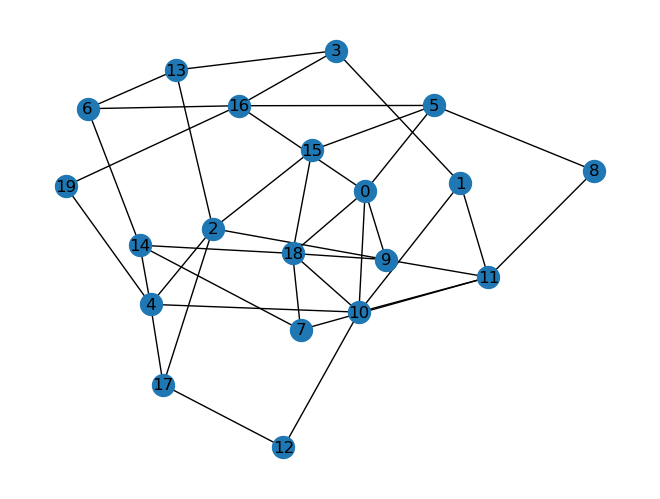

In [3]:
N=20;p=0.2
G=grafo_erd1(N=N,p=p)
nx.draw(G,with_labels=True,node_size=250)

In [4]:
num_ar=G.number_of_edges()
num_esperado_aristas=p*N*(N-1)/2
print(f"Numero de Aristas={num_ar}, y Numero esperado de aristas={num_esperado_aristas}")

Numero de Aristas=38, y Numero esperado de aristas=38.0


¿Por qué el número de aristas observado no tiene por qué coincidir exactamente con ⟨L⟩?

Ya que el numero esperado no coincide siempre con cada realizacion es solo el promedio que esperamos obtener utilizando N nodos con probabilidad p.

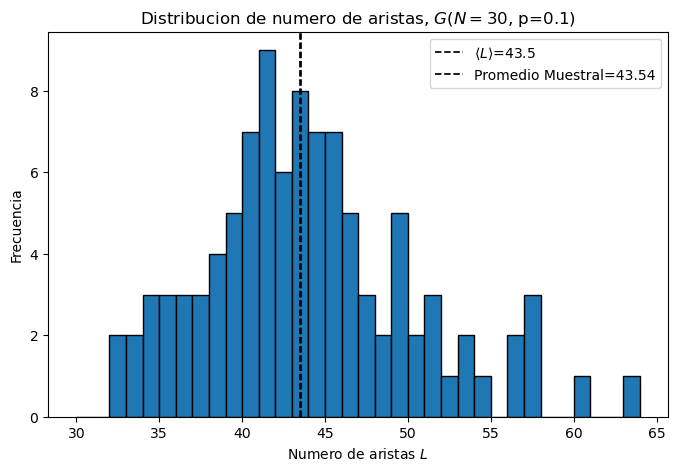

In [5]:
def simular_naristas(N, p, n_sim=1000):
    valores_L = []
    for s in range(n_sim):
        G = grafo_erd1(N,p,seed=s)
        valores_L.append(G.number_of_edges())
    return valores_L

N=30; p=0.1; n_sim=100
L_esp=p*N*(N-1)/2
valores_L= simular_naristas(N,p, n_sim=100)
prm_m=sum(valores_L)/n_sim
plt.figure(figsize=(8,5))
plt.hist(valores_L, bins=range(min(valores_L)-2,max(valores_L)+2), edgecolor="black")
plt.axvline(L_esp, linestyle="--", linewidth=1.25, color='black', label=fr"$\langle L\rangle$={round(L_esp,3)}")
plt.axvline(prm_m, linestyle="--", color='black', linewidth=1.25, label=fr"Promedio Muestral={round(prm_m,3)}")
plt.xlabel(fr"Numero de aristas $L$")
plt.ylabel(fr"Frecuencia")
plt.title(fr"Distribucion de numero de aristas, $G(N={N}$, p={round(p,3)})")
plt.legend()
plt.show()

Explique por qué, aun cuando los parámetros N y p son los mismos, distintas realizaciones pueden tener diferente número de aristas.

Ya que en cada realizacion se generan numeros aleatorioos distintos para deciidir que aristas poner y cuales no.

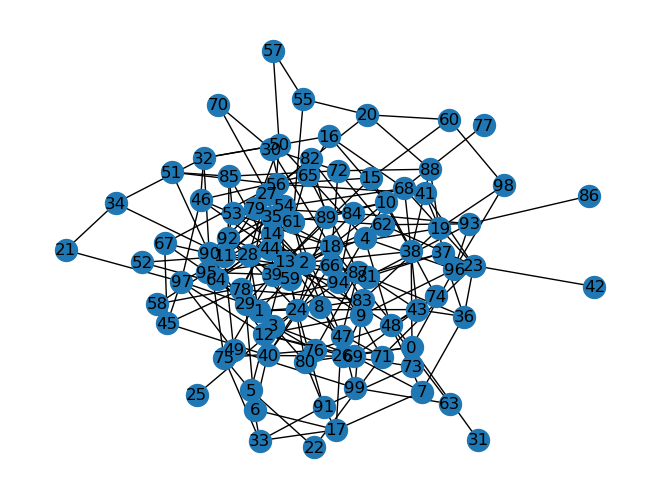

In [6]:
N=100;p=0.05
G=grafo_erd1(N=N,p=p)
nx.draw(G,with_labels=True,node_size=250)

In [7]:
degrees=list(G.degree())
mean_deg=2*(G.number_of_edges())/G.number_of_nodes()
deg_esp=0.05*(100-1)
print(f"Grado promedio Observado: {mean_deg}, y Grado Promedio esperado: {deg_esp}")

Grado promedio Observado: 4.64, y Grado Promedio esperado: 4.95


¿Por qué el promedio de grados está relacionado con el número de aristas mediante la expresión $\frac{2L}{N}$?



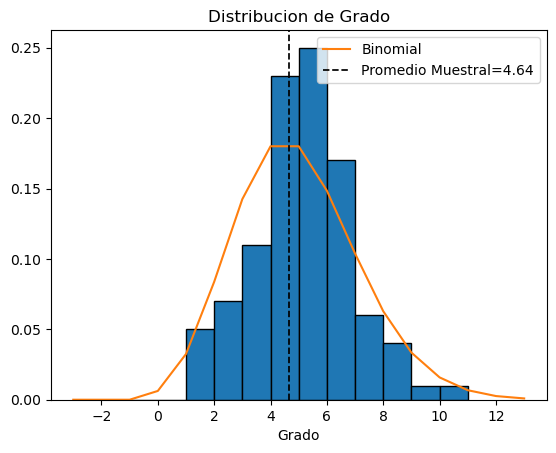

In [8]:
degs = [d for n, d in degrees]
m_deg=sum(degs)/len(degs)
k_vals=np.arange(min(degs)-4,max(degs)+4)
binom_pmf = binom.pmf(k_vals,N-1,p)
plt.hist(degs,density=True, bins=range(min(degs)-2,max(degs)+2), edgecolor="black")
plt.plot(k_vals,binom_pmf, label='Binomial')
plt.title("Distribucion de Grado")
plt.xlabel("Grado")
plt.axvline(m_deg, linestyle="--", color='black', linewidth=1.25, label=fr"Promedio Muestral={round(m_deg,3)}")
plt.legend()
plt.ylabel("")
plt.show()

N=50; p1=0.01; p2=0.05; p3=0.1; p4=0.2;
G1=grafo_erd1(N,p1,seed=10); G2=grafo_erd1(N,p2,seed=10);G3=grafo_erd1(N,p3,seed=10);G4=grafo_erd1(N,p4,seed=10)

0.01: L=9, k_prom=0.36, componentes=41
0.05: L=60, k_prom=2.4, componentes=4
0.1: L=123, k_prom=4.92, componentes=1
0.2: L=247, k_prom=9.88, componentes=1


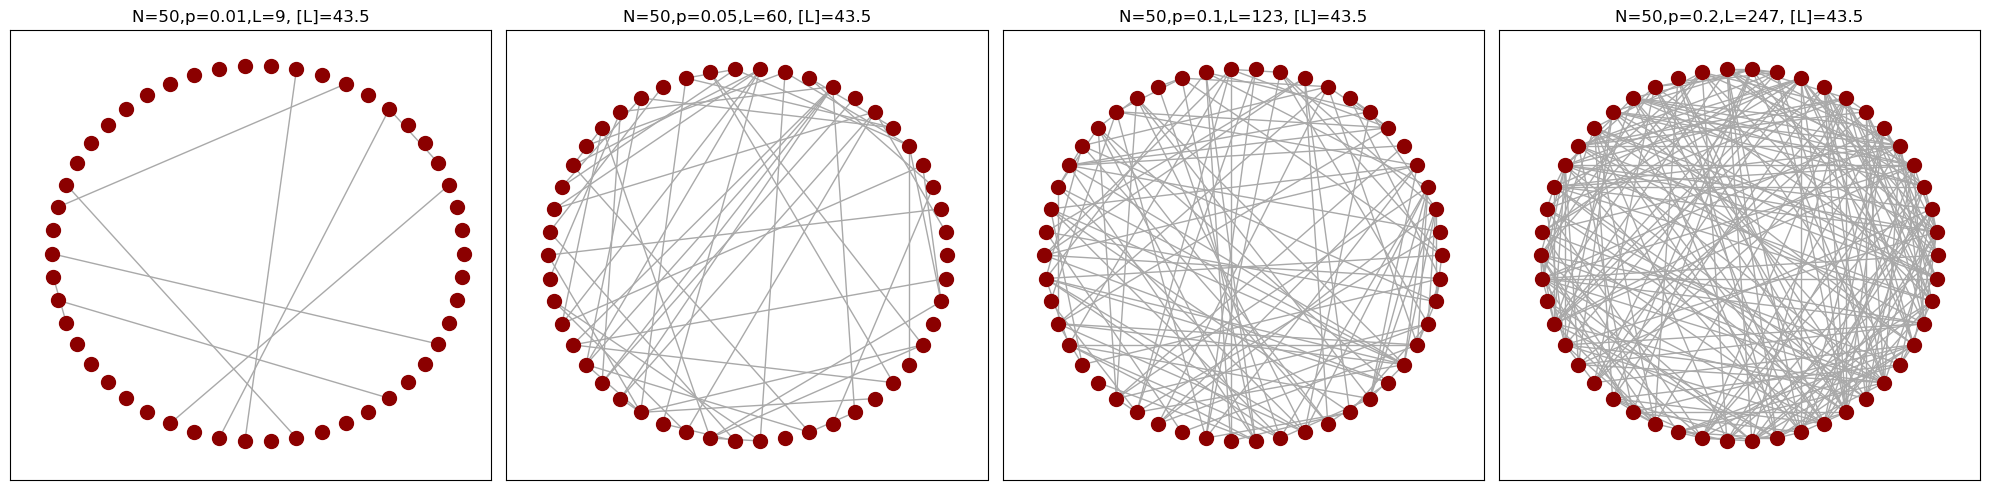

In [16]:
p_v = [0.01, 0.05, 0.1, 0.2]
N=50
G1=grafo_erd1(N,p_v[0]); G2=grafo_erd1(N,p_v[1]); G3=grafo_erd1(N,p_v[2]); G4=grafo_erd1(N,p_v[3])
grafos = [G1,G2,G3,G4] 

for p, G in zip(p_v, grafos):
    L = G.number_of_edges()
    g_prom = (2 * L) / N
    num_componentes = nx.number_connected_components(G)
    
    print(fr'{p}: L={L}, k_prom={g_prom}, componentes={num_componentes}')
n_real=len(grafos)
fig,axes=plt.subplots(1,n_real, figsize=(5*n_real,5))

for k, ax, G in zip([0,1,2,3],axes,grafos):
    pos=nx.circular_layout(G)
    p=p_v[k]
    L=G.number_of_edges()
    nx.draw_networkx_nodes(G,pos,ax=ax,node_size=100,node_color='darkred')
    nx.draw_networkx_edges(G,pos,ax=ax,node_size=100,edge_color='darkgray',width=1)
    ax.set_title(f"N={N},p={round(p, 3)},L={L}, [L]={round(L_esp,3)}",fontsize=12)
plt.tight_layout()
plt.show()

Describa cómo cambia la estructura de la red al aumentar el valor de p.

Cuando aumenta el valor de p la grafica se conecta mucho mas y se agregan muchas aristas.

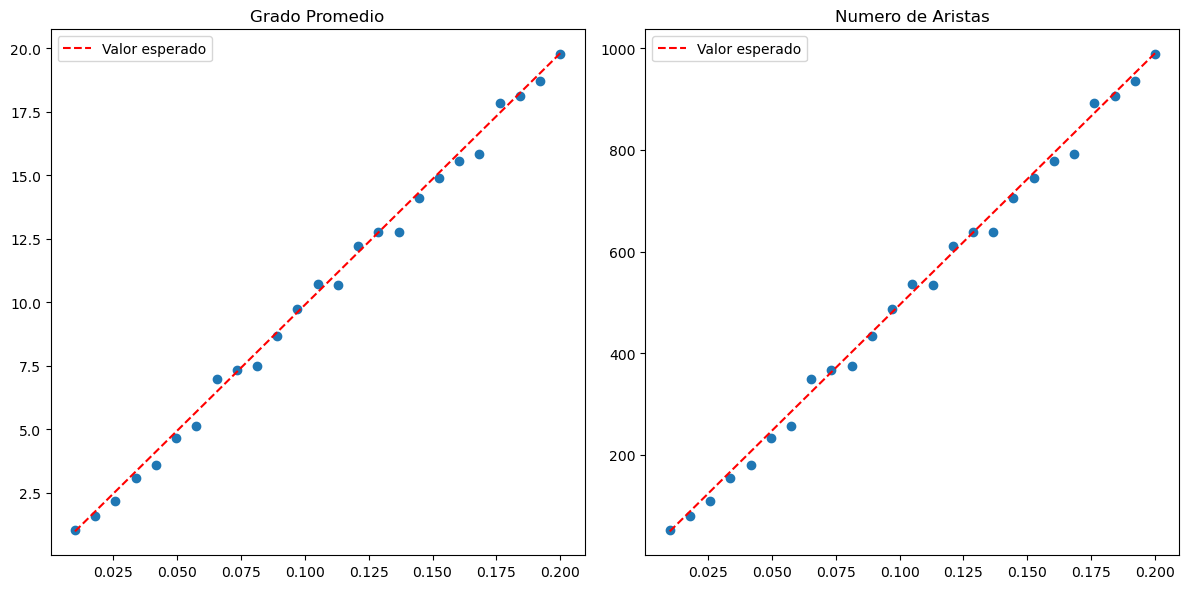

In [17]:
N=100;n=25; I = np.linspace(0.01, 0.2, n)
degsp=[]
degspp=[p*(N-1) for p in I]
ls=[]
lsesp=[p*(N*(N-1)/2) for p in I]
for p in I:
    G=grafo_erd1(N, p)
    L = G.number_of_edges()
    ls.append(L)
    g_prom = (2 * L) / N
    degsp.append(g_prom)

a=[degsp,ls]
b=[degspp,lsesp]
titulos=["Grado Promedio","Numero de Aristas"]
fig,axes=plt.subplots(1,2, figsize=(6*2,6))
for a,b,ax,title in zip(a,b,axes,titulos):
    ax.scatter(I, a)
    ax.plot(I, b, color='red', linestyle='--', label=f"Valor esperado")
    ax.set_title(title)
    ax.legend()
    
plt.tight_layout()
plt.show()

¿De qué manera dependen el número esperado de aristas y el grado promedio esperado del parámetro p?

Siguen una dependecia lineal